## Feature Engineering: Domain Knowledge-Based Features

In [1]:
%load_ext autoreload
%autoreload 2

Import libraries

In [2]:
import sys
from pathlib import Path

project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

Set up MLflow tracking URI and experiment name

In [3]:
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
mlflow.set_registry_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
experiment_name = "Production Time Prediction"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///D:/DEV/AIML/ProjectRepos/AzureML/templates/azureml/mlflow/artifacts', creation_time=1779115459900, experiment_id='1', last_update_time=1779115459900, lifecycle_stage='active', name='Production Time Prediction', tags={}, workspace='default'>

Read splitted data

In [4]:
import pandas as pd

X_train = pd.read_parquet('../../data/split/production_time_train.parquet')
X_test = pd.read_parquet('../../data/split/production_time_test.parquet')

y_train = pd.read_parquet('../../data/split/production_time_train_target.parquet')['process_time']
y_test = pd.read_parquet('../../data/split/production_time_test_target.parquet')['process_time']

numerical_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['op_w', 'op_l', 'wire_dia', 'mesh_fl', 'mesh_sp', 'batch_width', 'batch_length', 'qty']
Categorical columns: ['op_align', 'stand_type']



---
### 1. Feature Engineering: Domain Knowledge-Based Features
Domain knowledge-based feature engineering involves creating new features based on insights and understanding of the problem domain, leveraging expert knowledge. In the context of wire meshes production, we can create features that capture the physical and operational characteristics of the production process. The following features can be engineered based on domain knowledge:
- warp_wire_count
- weft_wire_count
- cross_section_count
- wire_weight_per_meter
- batch_area
- batch_volume

In [7]:
# constants
density_steel = 7850 # kg/m^3

In [8]:
import numpy as np

mat_allowance = 600 # mm, material allowance for weft wires

# warp wire count (longitudinal wires) and weft wire count (transverse wires)
mask = X_train['op_align'].isin(['A', 'S'])
X_train['weft_wire_count'] = np.ceil((X_train['batch_length'] - mat_allowance) / ( X_train['wire_dia'] +  np.where(mask, X_train['op_w'], X_train['op_l']) ))
X_train['warp_wire_count'] = np.ceil(X_train['batch_width'] / ( X_train['wire_dia'] + np.where(mask, X_train['op_l'], X_train['op_w']) ))

# cross-section count (number of wires in the cross-section)
X_train['cross_section_count'] = X_train['warp_wire_count'] * X_train['weft_wire_count']

# wire weight per meter (kg/m)
X_train['wire_weight_per_meter'] = 1 * (X_train['wire_dia'] / 1000) ** 2 * np.pi / 4 * density_steel

# batch area in m^2
X_train['batch_area'] = (X_train['batch_length'] / 1000) * (X_train['batch_width'] / 1000)

# batch volume in m^3
X_train['batch_volume'] = X_train['batch_area'] * (X_train['wire_dia'] / 1000)

new_candidate_features = ['warp_wire_count', 'weft_wire_count', 'cross_section_count', 'wire_weight_per_meter', 'batch_area', 'batch_volume']

from IPython.display import display, Markdown
n_count = 5
display(Markdown(f"### New Candidate Features Based on Domain Knowledge (First {n_count})"))
display(X_train[new_candidate_features].head(n_count).round(2))

### New Candidate Features Based on Domain Knowledge (First 5)

,warp_wire_count,weft_wire_count,cross_section_count,wire_weight_per_meter,batch_area,batch_volume
0,37.0,137.0,5069.0,0.22,6.22,0.04
1,121.0,811.0,98131.0,0.02,3.71,0.01
2,42.0,99.0,4158.0,0.26,6.38,0.04
3,32.0,63.0,2016.0,0.19,3.12,0.02
4,21.0,24.0,504.0,0.30,1.38,0.01


#### Feature vs Target Analysis: Original Features
Scatter plots of new features vs target variable to visually inspect relationships

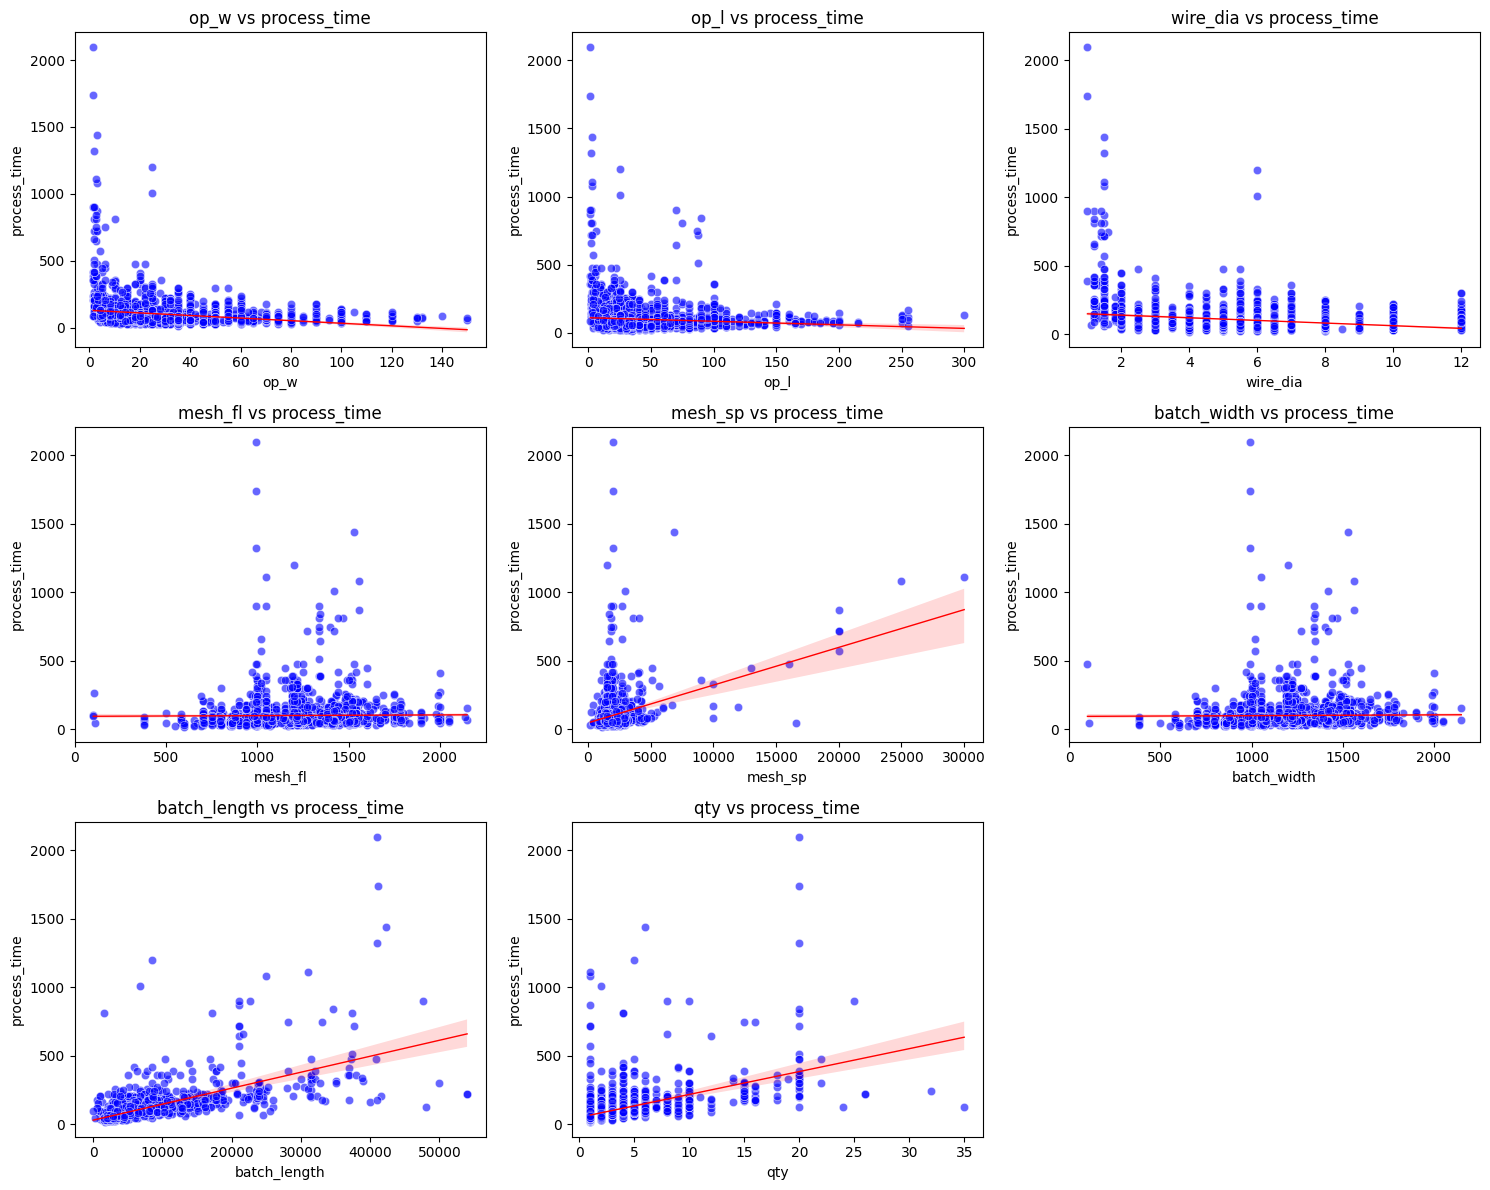

In [15]:
from notebooks.utils.feature_engineer.visualization import Visualization
feat_data = X_train.copy()
feat_data['process_time'] = y_train
Visualization.plot_feature_relationships(data=feat_data, cols=numerical_cols, color='blue')

For opening sizes there is visible relationship with target variable with target variance increasing with smaller opening sizes. 
Wire diameter scatterplot displays distinct values corresponding to different wire types, but without a clear relationship to the target variable.
Mesh width and batch width are nearly indentical due to the fact that they are in fact nearly the same measurement and do not show any visible relationship with target variable, but will be kept for further analysis as they may interact with other features and will be used for calculating new features.
Batch length shows the strongest relationship with target variable, with a clear positive correlation where longer batches tend to have higher process times. Similar case is with quantity, but this may be due to the fact, that quantity is statistically correlated with batch length, as longer batches tend to have more quantity.
I will keep the quantity feature anyway, as it also carry one more information about production process, which is the number of cuts performed on the batch, which may be relevant for process time.

#### Feature vs Target Analysis: Domain Knowledge-Based Features
Scatter plots of new features vs target variable to visually inspect relationships

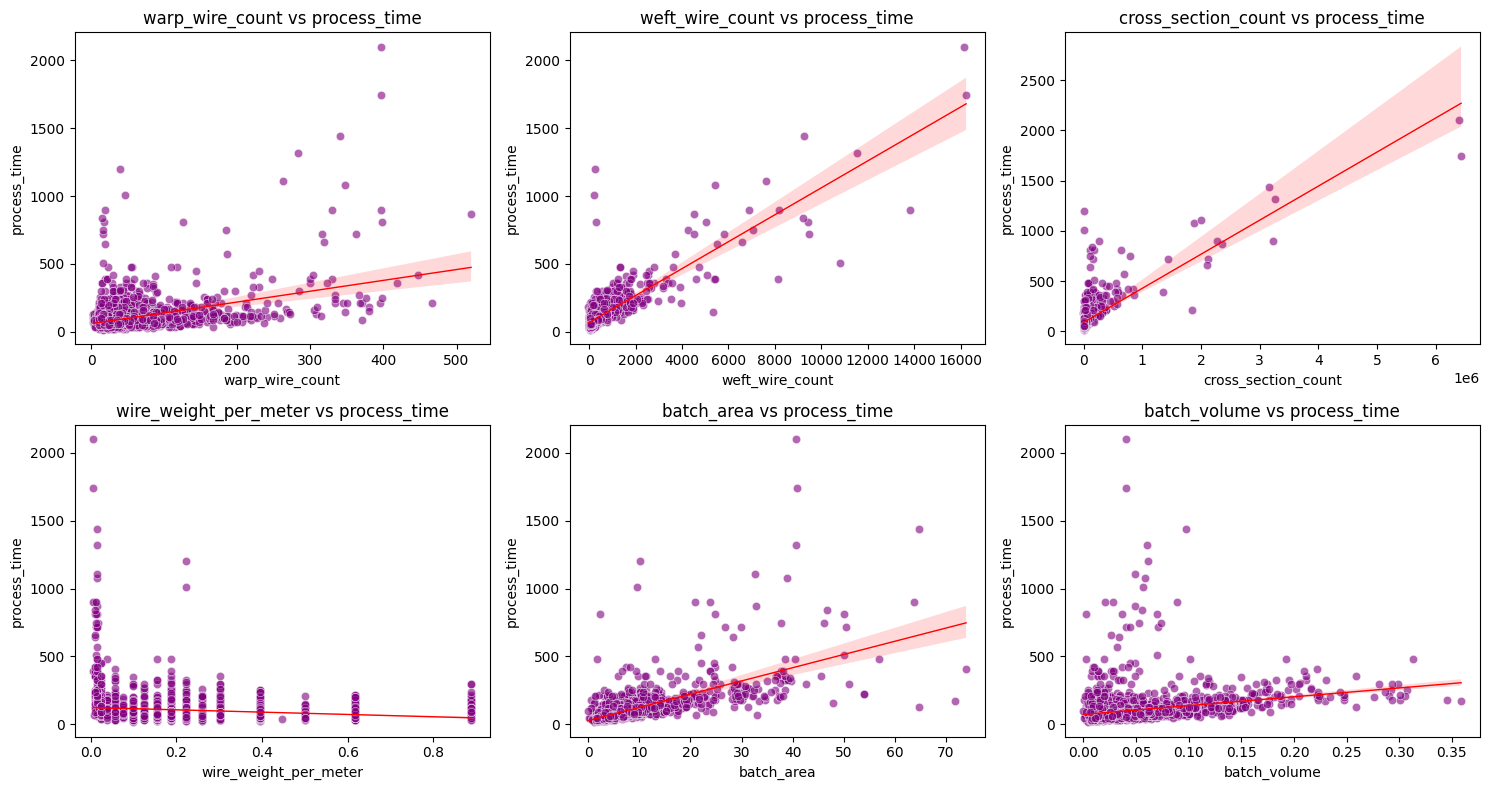

In [16]:
Visualization.plot_feature_relationships(feat_data, new_candidate_features, color='purple')
# Visualization.plot_feature_relationships(feat_data, new_candidate_features, filter_mask=feat_data['stand_type'] == 1, color='purple')

New engineered features based on domain knowledge show varying degrees of relationship with the target variable.
- Warp wire count and weft wire count show a positive correlation with process time, although they still exhibit some variance, suggesting that while they are relevant, other factors also influence process time.
- Cross-section count shows even more variance, but it was expected as it carries information that ignores batch dimensions, but there is visible relationship with target variable, as batches with more cross-sections tend to have higher process time.
- Wire weight per meter shows a negative correlation with process time, indicating that heavier wires may be processed faster, possibly due to the fact that they are used to produce meshes with larger openings which are faster to produce, but it cannot be definately concluded, because variance for lower wire weights is quite high and reach lower values similar to heavier wires, while heavier wires do not reach such high process times as lighter wires.
- Batch area shows a positive correlation with process time, but surprisingly not as clear as batch length.
- Batch volume on the other hand shows a very strong positive correlation with process time, and appear to eased the variance issue observed in batch length, indicating that combining all batch dimesions including wire diameter carries quite strong signal for predicting process time.

Overall the domain knowledge-based features look promising and will be further evaluated in the modeling phase to assess their contribution to improving model performance.

#### Feature Distributions by Stand Type
Visual examination of feature distributions across different stand types to identify potential differences in production processes or batch characteristics. Grouping by stand type was performed to isolate the effect of different production lines.

### Feature Distributions by Stand Type

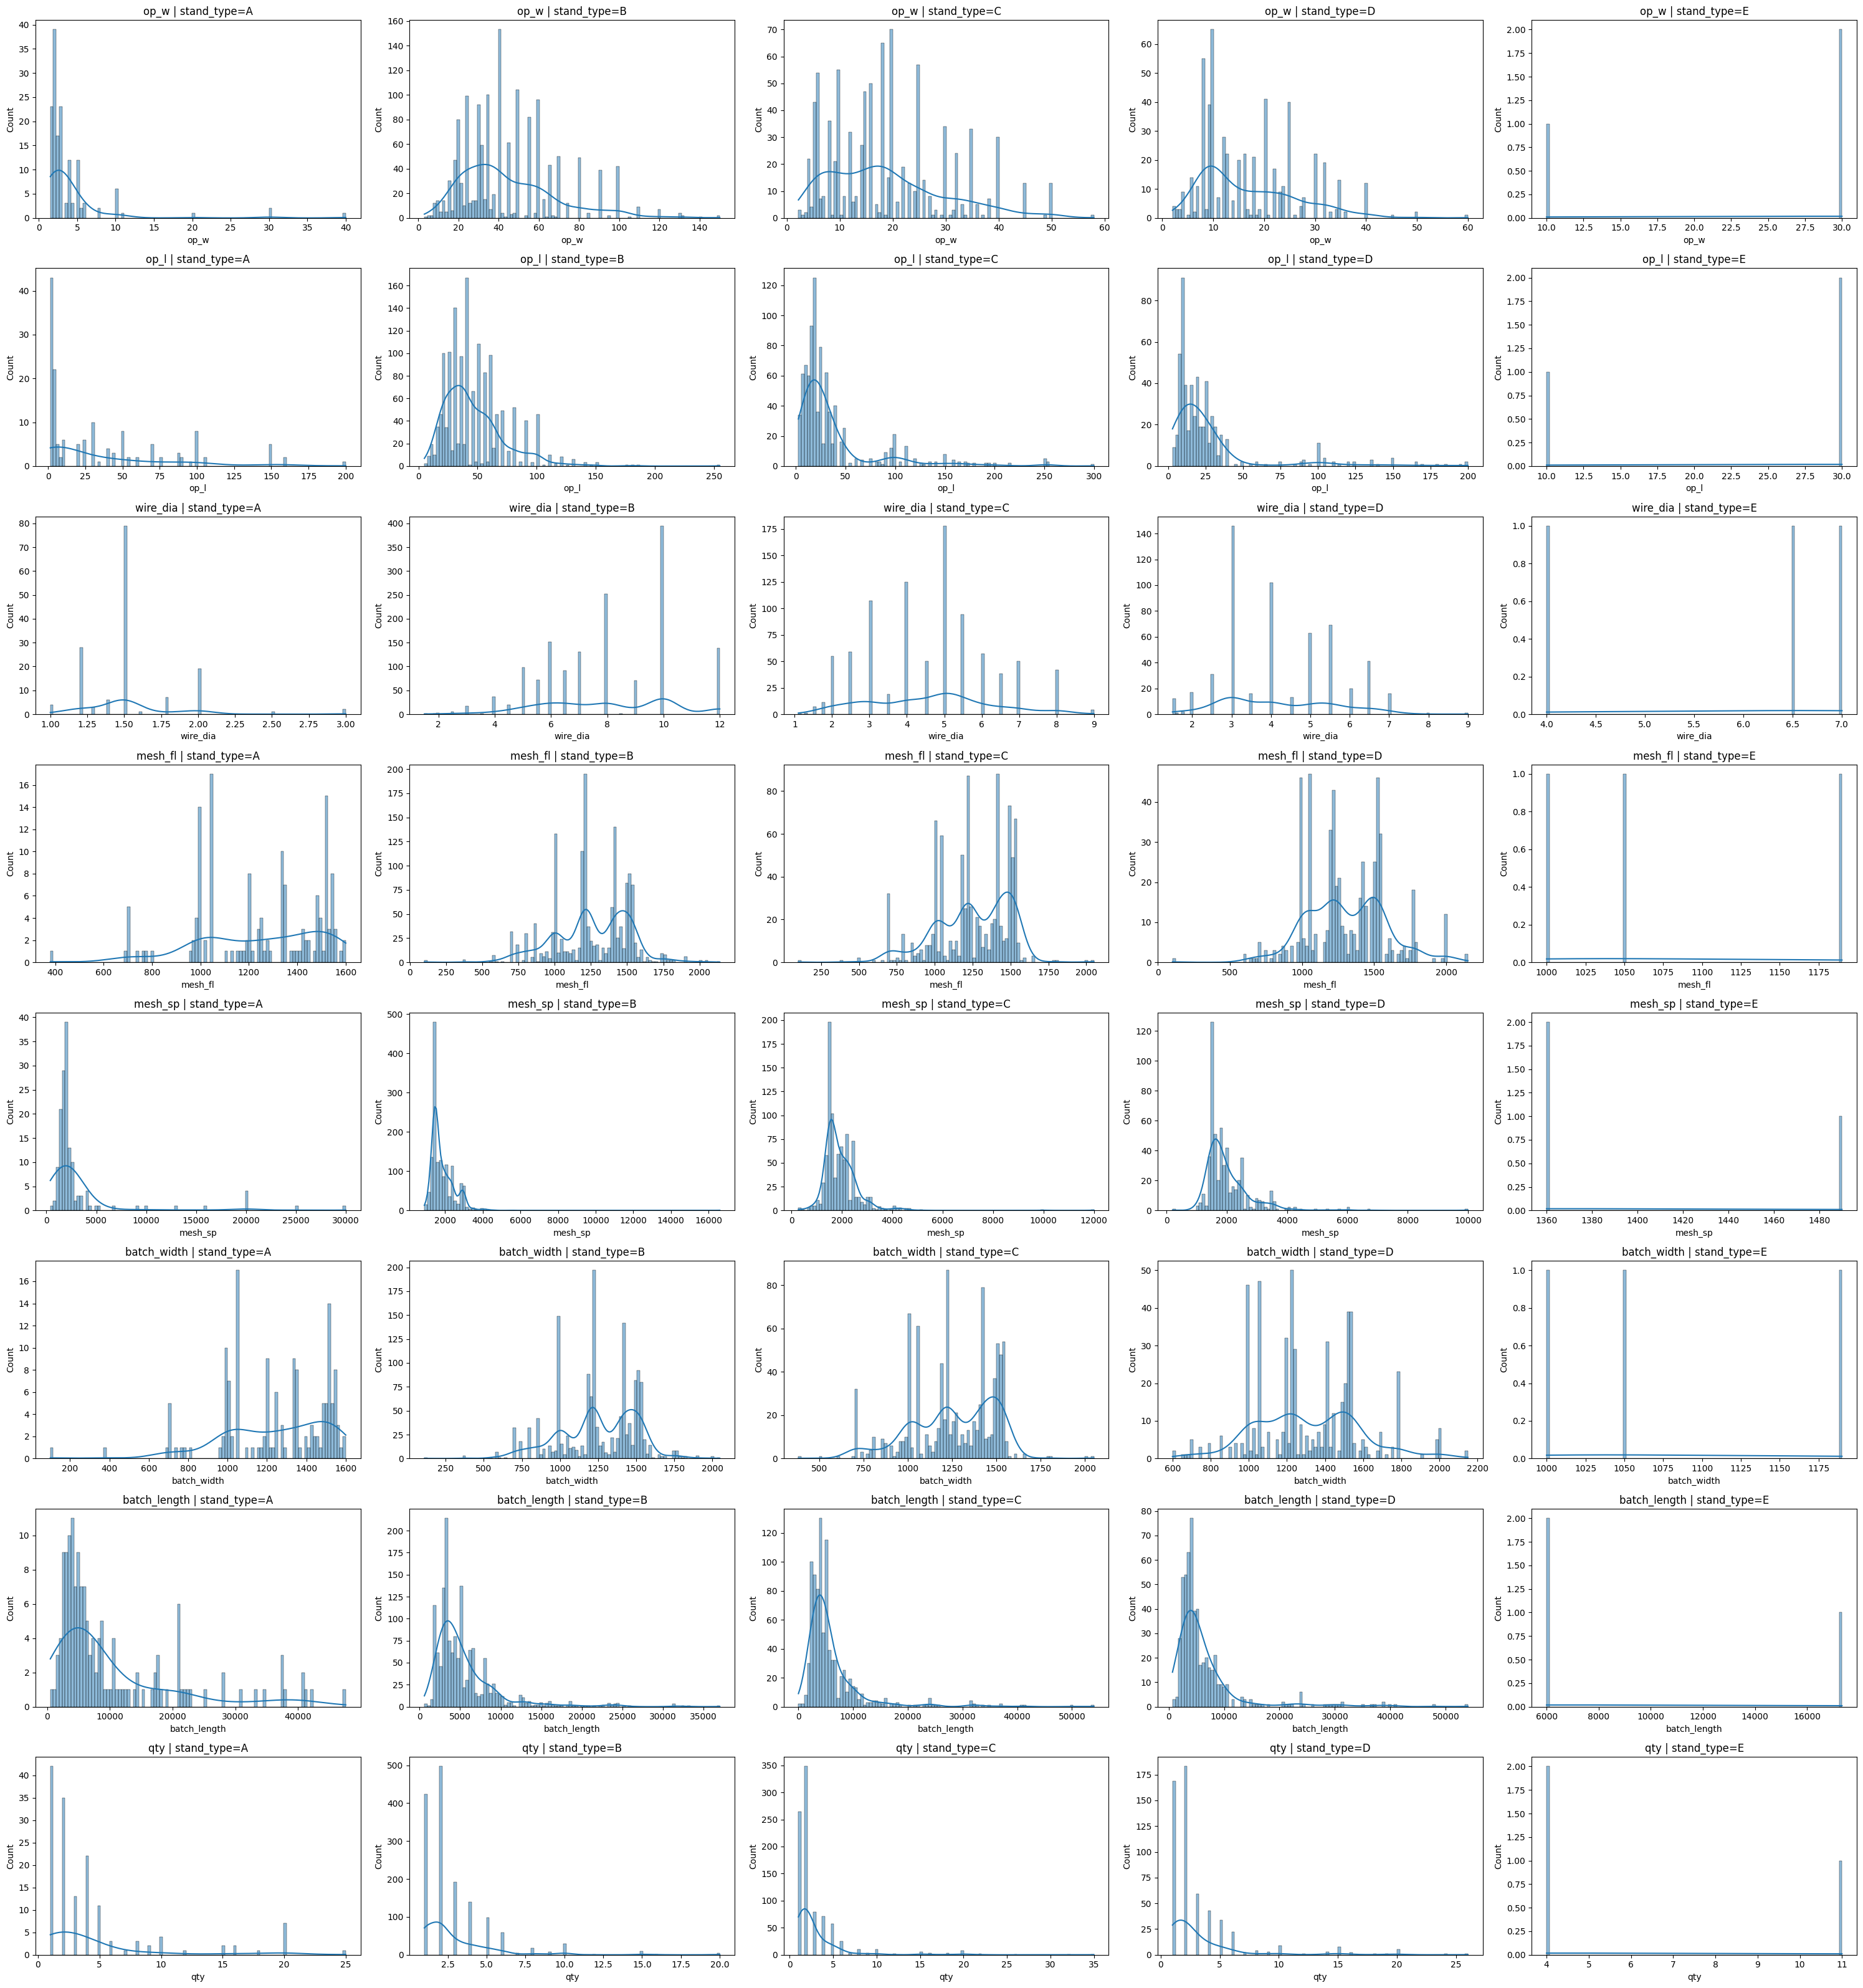

### New Candidate Feature Distributions by Stand Type

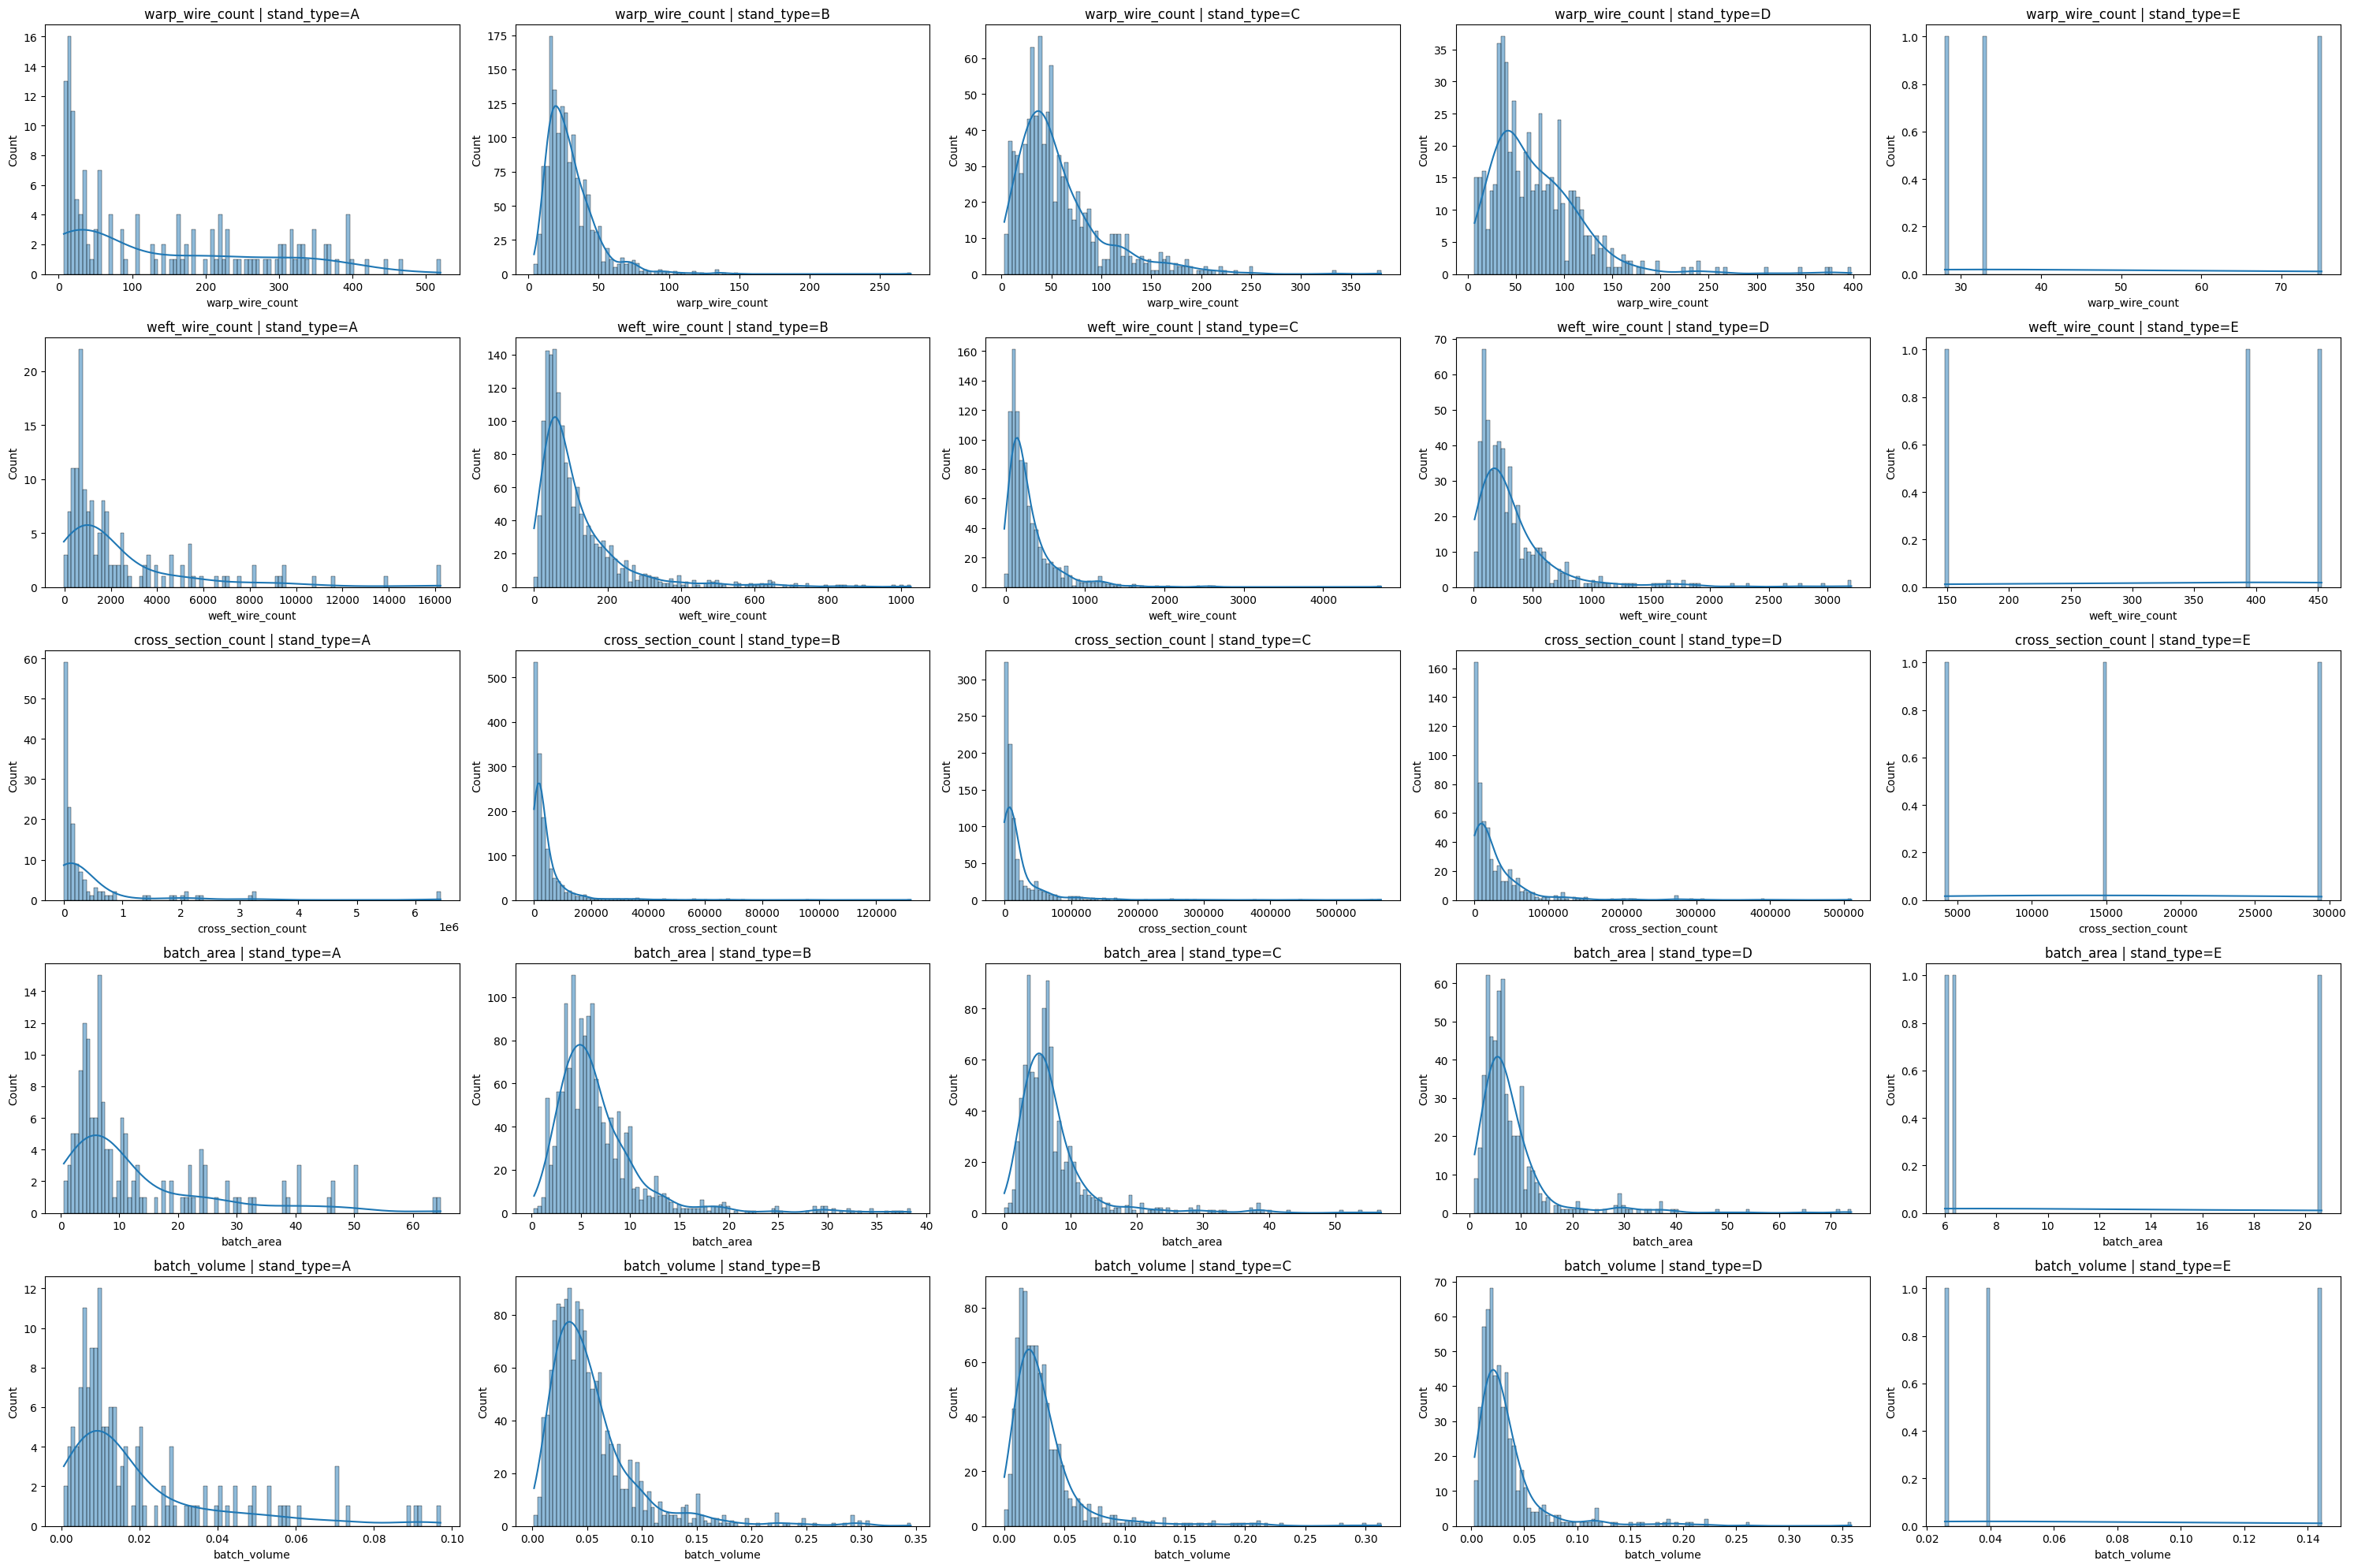

In [17]:
new_features = ['warp_wire_count', 'weft_wire_count', 'cross_section_count', 'batch_area', 'batch_volume']
bins = 100

display(Markdown(f"### Feature Distributions by Stand Type"))
Visualization.plot_feature_distributions(data=feat_data, cols=numerical_cols, bins=bins, per_cat='stand_type')

display(Markdown(f"### New Candidate Feature Distributions by Stand Type"))
Visualization.plot_feature_distributions(data=feat_data, cols=new_features, bins=bins, per_cat='stand_type')

Even with distinction between stand types, the original features exhibit a fragmented distribution with multiple local peaks and irregular spikes, suggesting a mixture of underlying regimes rather than a single smooth generating process. In most cases, the density is not stable across the range, indicating potential discreteness or strong interaction effects in the raw representation.

The new domain-based engineered features show a more stable and coherent distribution. While the distribution is right-skewed, it follows a smoother and more continuous shape, closer to a unimodal pattern. This suggests that the transformation reduces local irregularities and captures a more consistent underlying signal structure.

The applied feature engineering reduces multimodal artifacts observed in the raw space and produces a more regularized representation with improved distributional stability, introducing mild right skewness in each new feature. This indicates that the engineered features may provide a more robust basis for modeling by mitigating noise and capturing more meaningful relationships with the target variable.

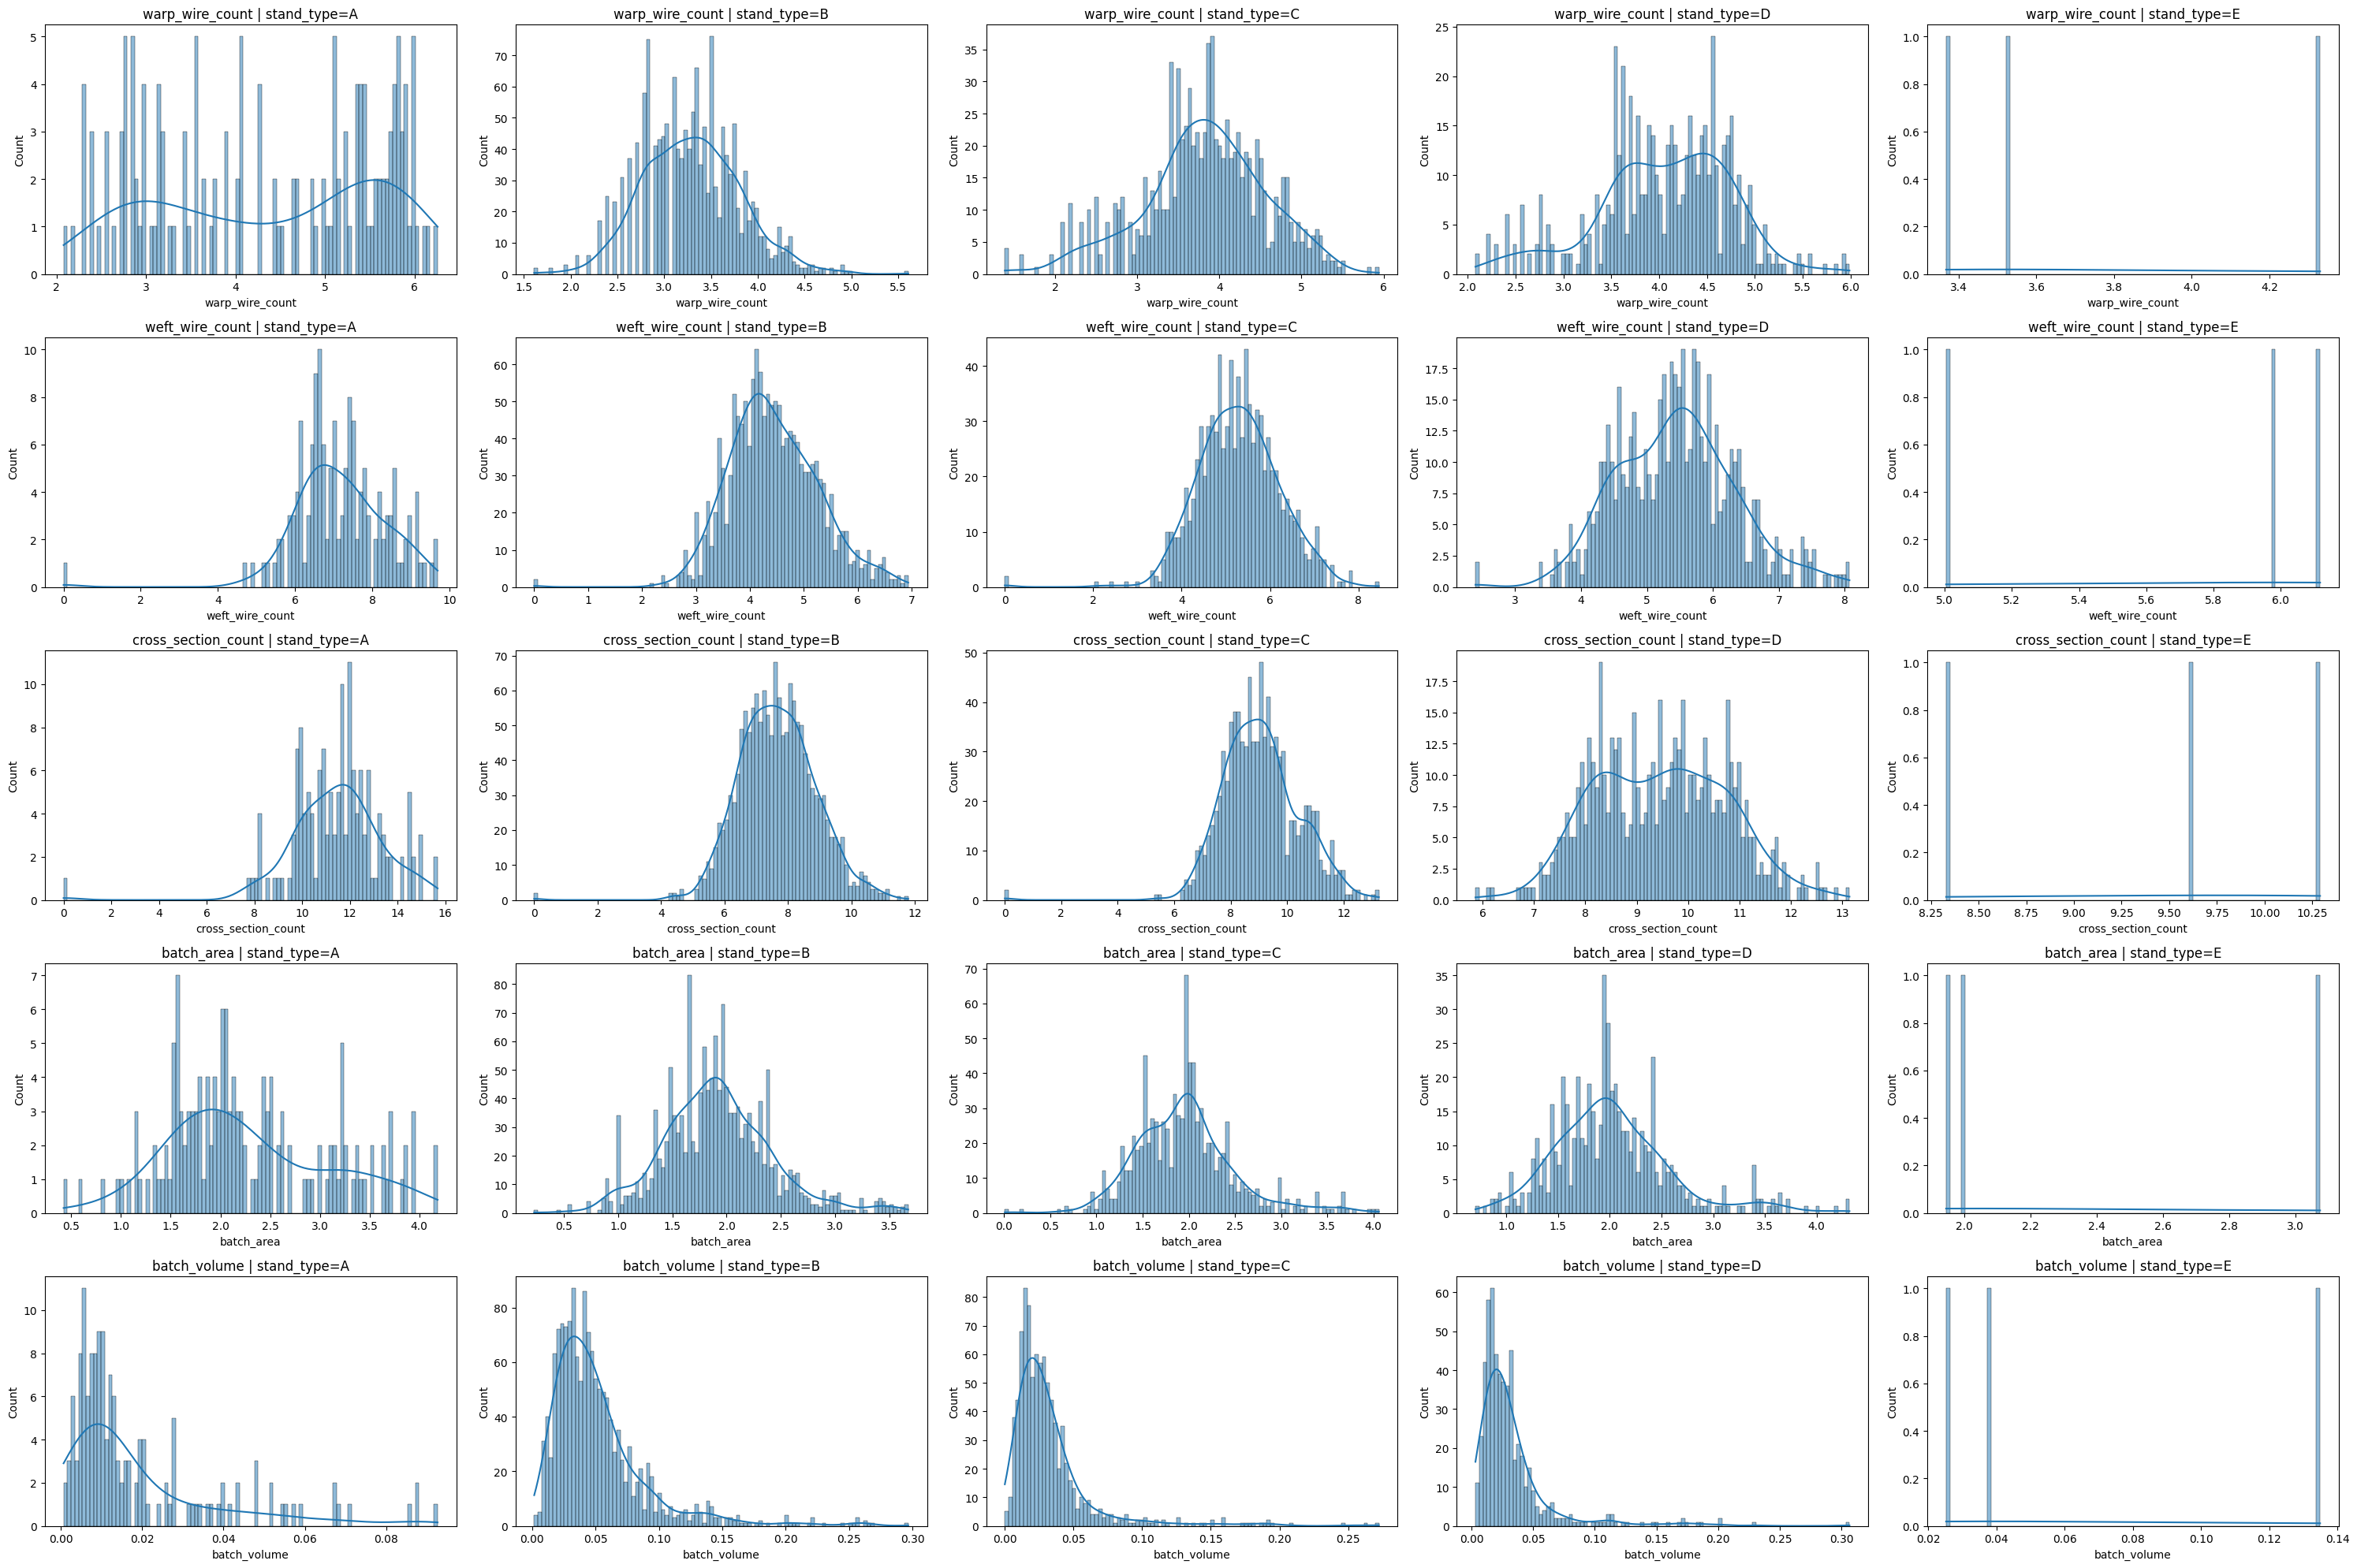

In [18]:
Visualization.plot_feature_distributions(data=feat_data, cols=new_features, bins=bins, per_cat='stand_type', log_scale=True)

#### Embodying Domain Knowledge in a Custom Transformer
To incorporate the domain knowledge-based features into a machine learning pipeline, I created a custom transformer class called `FeatureCreator` that inherits from `BaseEstimator` and `TransformerMixin`. This class implements the `fit` and `transform` methods to generate the new features based on the original input features. The new features are calculated using the relevant formulas derived from domain knowledge, and the resulting feature set is returned as a numpy array suitable for use in a scikit-learn pipeline.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


class FeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self, density_steel=7850, mat_allowance=600):
        """Custom transformer to create new features based on domain knowledge."""
        self.density_steel = density_steel
        self.mat_allowance = mat_allowance
    
    def fit(self, X, y=None):
        self.required_columns_ = [
            'op_align', 'op_w', 'op_l', 
            'batch_length', 'batch_width', 'wire_dia'
        ]

        missing = [c for c in self.required_columns_ if c not in X.columns]

        if missing:
            raise ValueError(f"Missing columns: {missing}")
        
        self.feature_names_in_ = np.array(X.columns, dtype=object)

        self.n_features_in_ = len(self.feature_names_in_)
        return self
    
    
    def transform(self, X):
        X = X.copy()

        mask = X['op_align'].isin(['A', 'S'])

        X['warp_wire_count'] = (
            np.ceil(X['batch_width'] /
            ( X['wire_dia'] + np.where(mask, X['op_l'], X['op_w']) ))
        )
        X['weft_wire_count'] = (
            np.ceil((X['batch_length'] - self.mat_allowance) / 
            ( X['wire_dia'] + np.where(mask, X['op_w'], X['op_l']) ))
        )

        X['cross_section_count'] = X['warp_wire_count'] * X['weft_wire_count']
        X['wire_weight_per_meter'] = 1 * (X['wire_dia'] / 1000) ** 2 * np.pi / 4 * self.density_steel
        X['batch_area'] = (X['batch_length'] / 1000) * (X['batch_width'] / 1000)
        X['batch_volume'] = X['batch_area'] * (X['wire_dia'] / 1000)

        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        
        new_features = [
            'warp_wire_count', 'weft_wire_count', 'cross_section_count', 
            'wire_weight_per_meter', 'batch_area', 'batch_volume'
        ]
        
        return np.concatenate([input_features, new_features])

#### Evaluating Feature Impact on Model Performance
To evaluate newly created features, I trained an Elastic Net regression model and XGBoost model using the engineered features, compared their performance with the base models, and performed coefficient analysis as a next step to identify which features are most influential in predicting the target variable.

To properly fit the model i used basic grid search with cross-validation on the training set to find the best hyperparameters for the Elastic Net model which roughtly oscillates between Ridge and Lasso regression, allowing for both feature selection and regularization. I included parameters found in optuna search for the base Lasso model as equivalents of Elastic Net parameters to ensure a fair comparison.

In [134]:
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

preprocessor = mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")
feature_creation_step = FeatureCreator()

grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('feature_creation', feature_creation_step),
        ('preprocess', preprocessor),
        ('enet', ElasticNet(max_iter=50000, random_state=42))
    ]),
    param_grid={
        "enet__alpha": [0.001, 0.01, 0.1, 0.122604, 1, 10],
        "enet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
    },
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="RMSE"
)

grid.fit(
    X=X_train,
    y=y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'enet__alpha': [0.001, 0.01, ...], 'enet__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'RMSE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [135]:
display(Markdown(f"#### Feature Names List:"))
print(grid.best_estimator_.named_steps['preprocess'].get_feature_names_out())

#### Feature Names List:

['op_align_A' 'op_align_B' 'op_align_S' 'stand_type_A' 'stand_type_B'
 'stand_type_C' 'stand_type_D' 'stand_type_E' 'op_w' 'op_l' 'wire_dia'
 'mesh_fl' 'mesh_sp' 'batch_width' 'batch_length' 'qty' 'weft_wire_count'
 'warp_wire_count' 'cross_section_count' 'wire_weight_per_meter'
 'batch_area' 'batch_volume']


Log Grid Search Results to MLflow<br/>
and Retrieve Best Model for Coefficient Analysis

In [136]:
from notebooks.utils.evaluation.log_grid_results import log_grid_results

scores, best_model_df = log_grid_results(
    grid_search=grid, 
    run_name="ElasticNet with Feature Engineering", 
    model_name="elasticnet_fe_model"
)

2026/05/20 13:27:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/20 13:27:47 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\singl\AppData\Local\Temp\tmplsgc8phz\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0']. Set logging level to DEBUG to see the full traceback. 


Logged baseline model and metrics to MLflow with run ID: b10a7540faff4b4cb2e0743be4dcbbe1

        To load the model later:
        mlflow.sklearn.load_model('runs:/{mlflow.last_active_run().info.run_id}/elasticnet_fe_model')


In [185]:
from IPython.display import display, Markdown
import ast
import pandas as pd

proc_time_ = feat_data['process_time']

display(Markdown("#### Best Model"))
display(pd.DataFrame([{
    'model_type': best_model_df.T['model_class'].iloc[0],
    **ast.literal_eval(best_model_df.T['params'].iloc[0])
}], index=['']).T)


display(pd.DataFrame({
    'Target Mean': f"{proc_time_.mean():.0f} minutes",
    'Target Range': f"{proc_time_.min():.0f} - {proc_time_.max():.0f} minutes"
}, index=['']))


display(Markdown("#### Baseline Model Cross-Validation Scores"))
display(scores)


#### Best Model

,
model_type,ElasticNet
enet__alpha,0.01
enet__l1_ratio,0.1


,Target Mean,Target Range
,102 minutes,15 - 2100 minutes


#### Baseline Model Cross-Validation Scores

,metric,mean_cv,fold_1,fold_2,fold_3,fold_4,fold_5
0,RMSE,39.2984,28.9186,56.2521,54.3929,27.4137,29.5148
1,MAE,18.2164,16.1426,20.7525,19.8222,16.9083,17.4564
2,R2,0.8389,0.8872,0.7650,0.7091,0.9056,0.9275


#### XGBoost Model with Engineered Features
To further evaluate the impact of the engineered features, I trained an XGBoost regression model using the same pipeline structure as the Elastic Net model, but replacing the estimator with `XGBRegressor` used as reference base model in the previous notebook to check if gap between linear and non-linear model can be reduced with the new features. I included parameters found in optuna search for the base model to ensure a fair comparison, and performed grid search with cross-validation to find the best hyperparameters for the XGBoost model.

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

_xgbr_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ('feature_creation', feature_creation_step),
        ('preprocess', preprocessor),
        ('xgb', XGBRegressor(n_estimators=216, random_state=42, max_depth=3))
    ]),
    param_grid={
        "xgb__learning_rate": [0.01, 0.062902,  0.1],
        "xgb__n_estimators": [50, 100, 200, 216, 300],
        "xgb__max_depth": [3, 5, 7]
    },
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    refit="RMSE"
)

_xgbr_grid.fit(
    X=X_train,
    y=y_train
)

_xgbr_scores, _xgbr_best_model_df = log_grid_results(
    grid_search=_xgbr_grid, 
    run_name="XGBRegressor with Feature Engineering", 
    model_name="xgbr_fe_model"
)

2026/05/20 12:54:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/20 12:54:40 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\singl\AppData\Local\Temp\tmpmrzqrxco\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.8.0']. Set logging level to DEBUG to see the full traceback. 


Logged baseline model and metrics to MLflow with run ID: cea1f86b25f342efa86eebfe26977ddc

        To load the model later:
        mlflow.sklearn.load_model('runs:/{mlflow.last_active_run().info.run_id}/xgbr_fe_model')


In [186]:
from IPython.display import display, Markdown
import ast
import pandas as pd

xgbr_proc_time_ = feat_data['process_time']

display(Markdown("#### Best Model with XGBoost"))
display(pd.DataFrame([{
    'model_type': _xgbr_best_model_df.T['model_class'].iloc[0],
    **ast.literal_eval(_xgbr_best_model_df.T['params'].iloc[0])
}], index=['']).T)


display(pd.DataFrame({
    'Target Mean': f"{xgbr_proc_time_.mean():.0f} minutes",
    'Target Range': f"{xgbr_proc_time_.min():.0f} - {xgbr_proc_time_.max():.0f} minutes"
}, index=['']))


display(Markdown("#### Baseline Model Cross-Validation Scores"))
display(_xgbr_scores)


#### Best Model with XGBoost

,
model_type,XGBRegressor
xgb__learning_rate,0.062902
xgb__max_depth,3
xgb__n_estimators,100


,Target Mean,Target Range
,102 minutes,15 - 2100 minutes


#### Baseline Model Cross-Validation Scores

,metric,mean_cv,fold_1,fold_2,fold_3,fold_4,fold_5
0,RMSE,42.3312,31.0952,58.9492,53.7165,36.4527,31.4426
1,MAE,18.5467,16.3525,20.3618,19.6269,17.8149,18.5772
2,R2,0.8157,0.8696,0.7419,0.7163,0.8330,0.9178


#### Model Performance Comparison

| Model | MAE | RMSE | R2 Score |
| --- | --- | --- | --- |
| ElasticNet with Feature Engineering | 39.2984 | 18.2164 | 0.8389 |
| Base XGBRegressor | 40.4949 | 17.9483 | 0.8210 |
| XGBRegressor with Feature Engineering | 42.3312 | 18.5467 | 0.8157 |
| Base Lasso | 62.3398 | 26.2644 | 0.6140 |

Results of a rough grid search already show significant improvement in model performance with the addition of domain knowledge-based features. Optimized for RMSE, the best linear model (ElasticNet) achieves a much lower error and a higher R2 score compared to the base Lasso model without feature engineering. This indicates that the new features provide valuable information that helps the model better capture the underlying patterns in the data and even outperform the more complex XGBRegressor base model in both RMSE and R2 score, which is a strong indication of the importance of feature engineering in this problem domain.

What's interesting to note is that the XGBoost model with engineered features did not outperform the Elastic Net model nor the base XGBoost model. In fact it got even slightly worse performance compared to the base XGBoost model, which may indicate that the new features are more beneficial for linear models like Elastic Net. The non-linear XGBoost model may already be able to capture some of the relationships in the data without the need for the engineered features, or it may require different hyperparameters to fully leverage the new features, but that is not the subject of this project as I solely focus on improving the linear model to outperform tree-based established baseline.

Now lets detect which features are zeroed out by ElasticNet and which are active (non-zero coefficients). This can give us insights into which features are considered important by the model and which ones are effectively ignored.

#### Coefficient Analysis of ElasticNet Model
Extracting and analyzing the coefficients of the Elastic Net model to identify which features are most influential inpredicting the target variable. Features with non-zero coefficients are considered active and contribute to the model's predictions, while features with zero coefficients are effectively ignored by the model. This analysis can provide insights into the importance of each feature and help identify which engineered features have the most impact on model performance.

In [142]:
import pandas as pd

best_model = grid.best_estimator_

coef_df = pd.DataFrame({
    "feature": best_model.named_steps["preprocess"].get_feature_names_out(),
    "coef": best_model.named_steps["enet"].coef_,
    "abs_coef": abs(best_model.named_steps["enet"].coef_)
})

# use min threshold to rule out non-meaningful features
threshold = 1e-5
zero_features = coef_df[coef_df["abs_coef"] < threshold]
active_features = coef_df[coef_df["abs_coef"] >= threshold]

from IPython.display import display, Markdown
display(Markdown("### Redundant (zeroed out) features:"))
display(zero_features.sort_values("abs_coef")[cols := ["feature", "coef"]]
        .reset_index(drop=True)
        .round(2))

display(Markdown("### Active features:"))
display(active_features.sort_values("abs_coef", ascending=False)[cols]
        .reset_index(drop=True)
        .round(2))

display(Markdown("#### Coefficient range:"))
print(f"{coef_df['coef'].min():.2f} to {coef_df['coef'].max():.2f}")

### Redundant (zeroed out) features:

,feature,coef


### Active features:

,feature,coef
0,weft_wire_count,38.34
1,cross_section_count,31.52
2,stand_type_A,23.04
3,stand_type_D,-18.21
4,qty,15.45
5,batch_area,14.78
6,op_align_B,13.39
7,wire_weight_per_meter,11.79
8,mesh_sp,10.56
9,op_align_S,-10.37


#### Coefficient range:

-18.21 to 38.34


No zeroed out features were observed in the best ElasticNet model, indicating that all features, including the engineered ones, contribute to the model's predictions. Coefficients range from `-18.21` to `38.34` so there is no extremes that would indicate model instability. The most influential features are `weft_wire_count`, `cross_section_count` which are engineered features, followed by `stand_type_A` and `stand_type_D` original features, showing that production stand may have impact on process time.

In [ ]:
# plot_utils.py
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(importance_df, top_n=20):
    """ Plots the top N most important features based on their weights."""
    top_features = importance_df.head(top_n) if len(importance_df) > top_n else importance_df
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='weight', y='feature', 
        data=top_features, 
        palette='viridis',
        hue='weight',
        )
    plt.title(f'Top {top_n} Feature Importances')
    plt.xlabel('Importance (Coefficient Weight)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


def plot_correlation_matrix(pipeline, X):
    """ Plots the correlation matrix of the features after transformation. """
    corr_matrix = pd.DataFrame(
        pipeline[:-1].transform(X), columns=pipeline[:-1].get_feature_names_out()
    ).corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title("Correlation Matrix of Features")
    plt.tight_layout()
    plt.show()

##### Save `plot_feature_importance` and `plot_correlation_matrix` functions
to file: `notebooks/utils/utilities/plot_utils.py`

In [6]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path="../utils/utilities/plot_utils.py",
    )

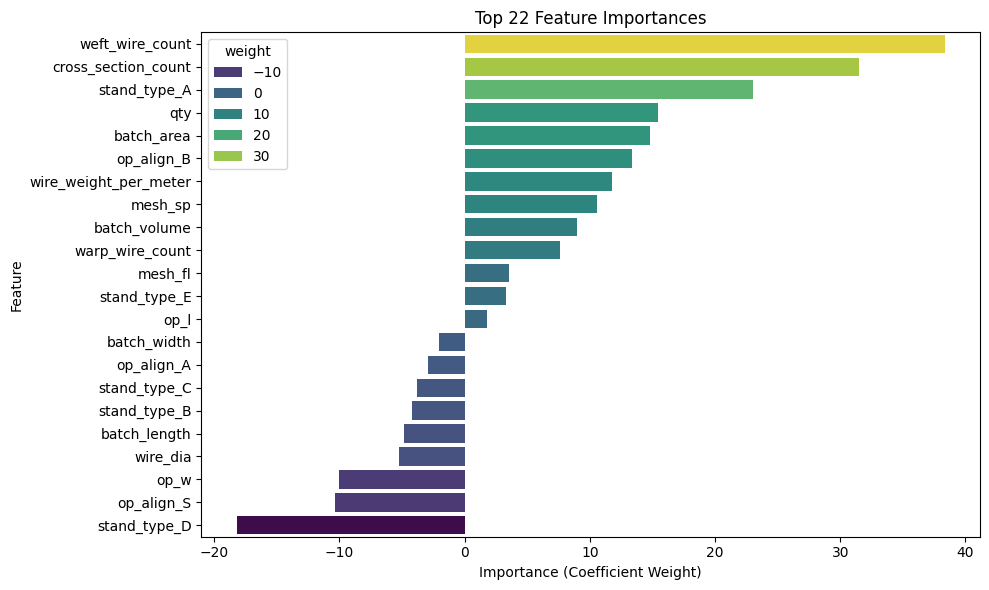

In [ ]:
best_model = grid.best_estimator_

# get feature names after one-hot encoding and feature engineering
feature_names = grid.best_estimator_[-2].get_feature_names_out() # doesn
model_coefs = grid.best_estimator_[-1].coef_

importances = (
    pd.Series(model_coefs, index=feature_names)
    .sort_values(ascending=False)
    .reset_index()
)

importances.columns = ['feature', 'weight']

plot_feature_importance(
    importance_df=importances,
    top_n=len(importances)
)

#### Log FeatureCreator to MLflow
To ensure reproducibility and track the feature engineering process, I logged the `FeatureCreator` custom transformer to MLflow for ease of use in future experiments and to maintain a record of the transformations applied to the data.

In [188]:
display(float(scores['mean_cv'][0]))
display(grid.best_params_)

display(float(_xgbr_scores['mean_cv'][0]))
display(_xgbr_grid.best_params_)

39.2984

{'enet__alpha': 0.01, 'enet__l1_ratio': 0.1}

42.3312

{'xgb__learning_rate': 0.062902, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}

In [189]:
import mlflow.sklearn

# ========================================
# Feature Creation Pipeline Step Logging
# =======================================
with mlflow.start_run(run_name="feature_engineering") as run:
    mlflow.sklearn.log_model(
        feature_creation_step,
        name="feature_creation_step",
        registered_model_name="feature_creation", # register the model in MLflow Model Registry
        pyfunc_predict_fn="transform"
    )
    print("""
    To load the feature creation pipeline later:
    feature_creation_step = mlflow.sklearn.load_model("models:/feature_creation/latest")
    """)

# ========================================
# Best Linear Model Results Logging
# ========================================
with mlflow.start_run(run_name="linear_model_domain_features") as run:
    print("Logging parameters and metrics of the best linear model...")
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("rmse", float(scores['mean_cv'][0]))
    mlflow.log_metric("mae", float(scores['mean_cv'][1]))
    mlflow.log_metric("r2", float(scores['mean_cv'][2]))

    print("Best linear model parameters and metrics logged to MLflow.")

# ========================================
# Best XGBoost Model Results Logging
# ========================================
with mlflow.start_run(run_name="tree_model_domain_features") as run:
    print("Logging parameters and metrics of the best tree model...")
    mlflow.log_params(_xgbr_grid.best_params_)
    mlflow.log_metric("rmse", float(_xgbr_scores['mean_cv'][0]))
    mlflow.log_metric("mae", float(_xgbr_scores['mean_cv'][1]))
    mlflow.log_metric("r2", float(_xgbr_scores['mean_cv'][2]))

    print("Best tree model parameters and metrics logged to MLflow.")

2026/05/20 23:45:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



    To load the feature creation pipeline later:
    feature_creation_step = mlflow.sklearn.load_model("models:/feature_creation/latest")
    
Logging parameters and metrics of the best linear model...
Best linear model parameters and metrics logged to MLflow.
Logging parameters and metrics of the best tree model...
Best tree model parameters and metrics logged to MLflow.


Registered model 'feature_creation' already exists. Creating a new version of this model...
Created version '2' of model 'feature_creation'.


In [ ]:
from notebooks.utils.utilities.get_run_metrics import get_latest_metrics_for_run
from mlflow.tracking import MlflowClient

client = MlflowClient()

for run_name in ["linear_model_domain_features", "tree_model_domain_features"]:
    get_latest_metrics_for_run(run_name=run_name, client=client, verbose=True)


Latest run of 'linear_model_domain_features' metrics:
--------------------------------------------------
Best RMSE: 39.2984
Best MAE: 18.2164
Best R2: 0.8389
Model parameters:
  enet__alpha: 0.01
  enet__l1_ratio: 0.1

Latest run of 'tree_model_domain_features' metrics:
--------------------------------------------------
Best RMSE: 42.3312
Best MAE: 18.5467
Best R2: 0.8157
Model parameters:
  xgb__learning_rate: 0.062902
  xgb__max_depth: 3
  xgb__n_estimators: 100


run names for later retrieval of metrics
- 'linear_domain_features_model'
- 'tree_domain_features_model'

---
---